In [64]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

In [ ]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


<font color=cyan>检验一下之前算的双云的约化卡方，是否是合理的拟合，计算过程在draw_image5，就不拿过来了</font>

In [66]:
from double_cloud_pixel_fit import fit_double_cloud_cube

result = fit_double_cloud_cube(
    data_cube=rsm[1].data[44:96, 789:806, 1515:1526],
    wavelength=lam00[44:96],
    I0=rsm[1].data[44:96, 797:826, 1540:1569].mean(axis=(1, 2)),
    y_start=789,
    x_start=1515,
    output_dir=r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\double_cloud",
    n_global_runs=30,
)

vL_map = result["vL"]        # 下层云速度，(17, 11)，km/s
vU_map = result["vU"]        # 上层云速度，(17, 11)，km/s
params = result["params"]   # 全部参数，(17, 11, 8)

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def plot_double_cloud_reduced_chi2(run_dir, save=True):
    """读取已有双云拟合结果，按 sigma=sqrt(I_obs) 计算约化卡方，不重新拟合。"""
    run_dir = Path(run_dir)
    with np.load(run_dir / "input_spectra.npz", allow_pickle=False) as f:
        observed = f["data_cube"].astype(float)
        wavelength = f["wavelength"]
        background = f["I0"]

    with np.load(run_dir / "fit_maps.npz", allow_pickle=False) as f:
        fitted = f["model"].astype(float)
        param_names = f["param_names"]
        success = f["success"].astype(bool)
        y_pixels = f["y_pixels"]
        x_pixels = f["x_pixels"]

    if observed.shape != fitted.shape:
        raise ValueError("观测光谱和拟合光谱的形状不一致。")

    n_params = len(param_names)
    valid = np.isfinite(observed) & np.isfinite(fitted) & (observed > 0)
    valid &= np.isfinite(wavelength)[:, None, None] & np.isfinite(background)[:, None, None]

    # 非正强度无法使用 sigma=sqrt(I_obs)，排除后相应调整有效点数及自由度。
    contributions = np.zeros_like(observed)
    np.divide((observed - fitted)**2, 22.42**2, out=contributions, where=valid)#这个22.42是误差定值（问的邱老师）
    n_valid = valid.sum(axis=0)
    dof = n_valid - n_params
    chi2 = contributions.sum(axis=0)
    chi2[n_valid == 0] = np.nan
    reduced_chi2 = np.full(observed.shape[1:], np.nan)
    np.divide(chi2, dof, out=reduced_chi2, where=dof > 0)

    finite = np.isfinite(reduced_chi2)
    if not finite.any():
        raise ValueError("没有可计算约化卡方的像素，请检查保存的观测和拟合数据。")

    fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("lightgray")
    extent = (x_pixels[0] - 0.5, x_pixels[-1] + 0.5, y_pixels[0] - 0.5, y_pixels[-1] + 0.5)
    im = ax.imshow(np.ma.masked_invalid(reduced_chi2), origin="lower", extent=extent, cmap=cmap, interpolation="nearest", aspect="equal")
    fig.colorbar(im, ax=ax, label=r"Reduced $\chi^2$ ($\sigma_i^2=22.82^2$)")
    ax.set(xlabel="X (original pixel)", ylabel="Y (original pixel)", title=f"Double-cloud fit: reduced chi-square\nN = {observed.shape[0]}, free parameters = {n_params}")

    # 保留未收敛像素的诊断值，同时用红叉标记。
    failed_y, failed_x = np.where(finite & ~success)
    if failed_y.size:
        ax.scatter(x_pixels[failed_x], y_pixels[failed_y], marker="x", c="red", s=35, label="Optimizer not converged")
        ax.legend(fontsize=9)

    values = reduced_chi2[finite]
    print(f"空间范围：y={y_pixels[0]}:{y_pixels[-1] + 1}, x={x_pixels[0]}:{x_pixels[-1] + 1}")
    print(f"自由参数：{n_params}；有效采样点数：{n_valid[finite].min()}–{n_valid[finite].max()}")
    print(f"有效自由度：{dof[finite].min()}–{dof[finite].max()}")
    print(f"约化卡方：min={values.min():.4g}, median={np.median(values):.4g}, max={values.max():.4g}")

    if save:
        np.savez_compressed(run_dir / "reduced_chi2_maps.npz", reduced_chi2=reduced_chi2, chi2=chi2, dof=dof, n_valid=n_valid, n_params=n_params, success=success, x_pixels=x_pixels, y_pixels=y_pixels, variance_assumption="variance = observed intensity")
        fig.savefig(run_dir / "reduced_chi2_map.png", dpi=300, bbox_inches="tight")
        fig.savefig(run_dir / "reduced_chi2_map.pdf", bbox_inches="tight")
        print(f"已保存到：{run_dir}")

    return fig, ax, reduced_chi2

空间范围：y=789:806, x=1515:1526
自由参数：8；有效采样点数：52–52
有效自由度：44–44
约化卡方：min=0.004895, median=0.03884, max=0.1525


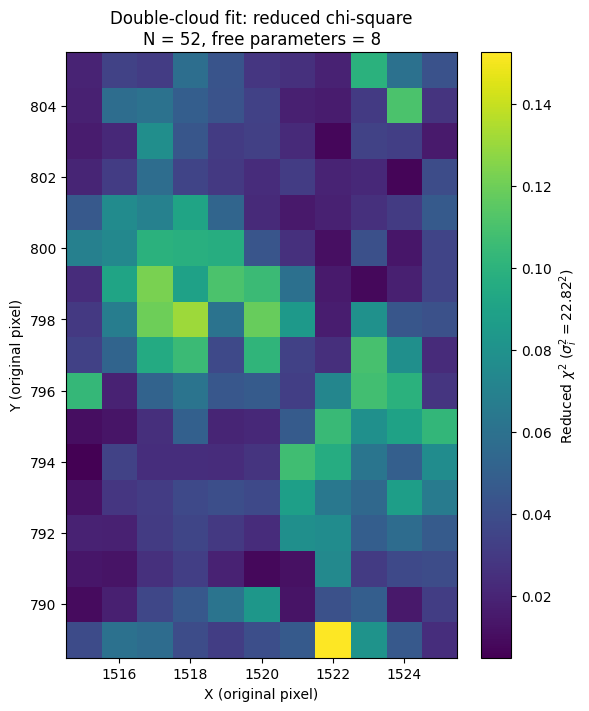

In [ ]:
run_dir = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\double_cloud\run_20260909_094035_195361")
fig, ax, reduced_chi2 = plot_double_cloud_reduced_chi2(run_dir,save=False)
plt.show()

<font color=cyan>用约化卡方看看单云拟合的怎么样</font>

In [ ]:
rsm=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits')

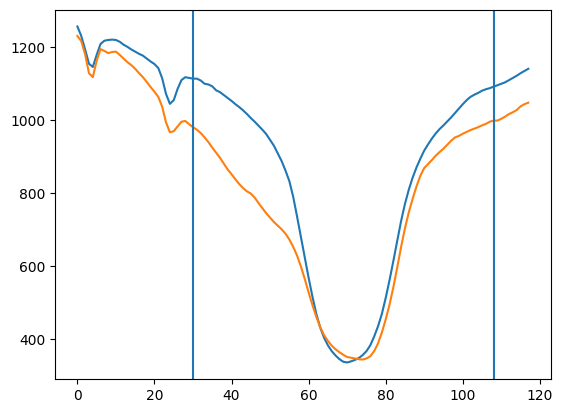

In [ ]:
curve=rsm[1].data[:,789,1515]
curve2=rsm[1].data[:,800,1520]
plt.plot(curve)
plt.plot(curve2)
plt.axvline(x=30)
plt.axvline(x=108)

In [ ]:
import importlib
import single_cloud_pixel_fit as sc

importlib.reload(sc)  # 加载修改后的代码

result_single = sc.fit_single_cloud_cube(
    data_cube=rsm[1].data[30:108, 789:806, 1515:1526],
    wavelength=lam00[30:108],
    I0=rsm[1].data[30:108, 797:826, 1540:1569].mean(axis=(1, 2)),
    lam0=None,                  # 根据共同参考背景确定
    background_core_points=7,   # 线心附近的拟合点数
    n_jobs=16,
    n_global_runs=30,
)

print("采用的背景线心：", result_single["lam0"], "Å")

Single cloud: 187 pixels, 16 workers, 30 searches/pixel
C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud\run_20260915_105108_475167
Shared wavelength zero point: 6562.86743525 Angstrom (background_core_quadratic)
[1/187] y=789, x=1516, v=-2.205, RMSE=7.074, success=True, elapsed=7.6s
[2/187] y=789, x=1523, v=13.280, RMSE=21.41, success=True, elapsed=7.6s
[3/187] y=790, x=1519, v=1.388, RMSE=12.76, success=True, elapsed=7.6s
[4/187] y=790, x=1515, v=-4.540, RMSE=6.819, success=True, elapsed=7.6s
[5/187] y=789, x=1517, v=0.529, RMSE=8.506, success=True, elapsed=7.6s
[6/187] y=790, x=1517, v=2.392, RMSE=15.26, success=True, elapsed=7.6s
[7/187] y=789, x=1515, v=-3.353, RMSE=7.04, success=True, elapsed=7.6s
[8/187] y=789, x=1524, v=9.024, RMSE=12.71, success=True, elapsed=7.6s
[9/187] y=789, x=1525, v=9.602, RMSE=8.678, success=True, elapsed=7.6s
[10/187] y=790, x=1518, v=3.149, RMSE=15.03, success=True, elapsed=7.6s
[11/187] y=789, x=1520, v=2.309, RMSE=16.74, succ

In [80]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def plot_single_cloud_reduced_chi2(run_dir, y_start=None, x_start=None, contour_level=800, vmax=None, save=True):
    """按 sigma=sqrt(I_obs) 计算已有单云拟合的约化卡方，并绘制二维图。"""
    run_dir = Path(run_dir)
    with np.load(run_dir / "input_spectra.npz", allow_pickle=False) as f:
        observed = f["data_cube"].astype(float)
        wavelength = f["wavelength"]
        background = f["I0"]

    with np.load(run_dir / "fit_maps.npz", allow_pickle=False) as f:
        fitted = f["model"].astype(float)
        n_params = len(f["param_names"])
        success = f["success"].astype(bool)
        y_pixels = f["y_pixels"]
        x_pixels = f["x_pixels"]

    if observed.shape != fitted.shape:
        raise ValueError("观测光谱与拟合光谱形状不一致。")

    n_wave, ny, nx = observed.shape
    # 可修正拟合时未传入 y_start/x_start 导致的坐标标签偏移，不改变数据。
    if y_start is not None:
        y_pixels = np.arange(y_start, y_start + ny)
    if x_start is not None:
        x_pixels = np.arange(x_start, x_start + nx)

    valid = np.isfinite(observed) & np.isfinite(fitted) & (observed > 0)
    valid &= np.isfinite(wavelength)[:, None, None] & np.isfinite(background)[:, None, None]

    # 排除无效采样点，同时调整每个像素的自由度。
    contributions = np.zeros_like(observed)
    np.divide((observed - fitted)**2, 22.42**2, out=contributions, where=valid)#这个22.42是误差定值（问的邱老师）
    n_valid = valid.sum(axis=0)
    dof = n_valid - n_params
    chi2 = contributions.sum(axis=0)
    chi2[n_valid == 0] = np.nan
    reduced_chi2 = np.full((ny, nx), np.nan)
    np.divide(chi2, dof, out=reduced_chi2, where=dof > 0)

    finite = np.isfinite(reduced_chi2)
    if not finite.any():
        raise ValueError("没有可计算约化卡方的像素。")

    # 输入光谱的前 10 层，对应本次原始 FITS 波长索引 44:54。
    ha_image = np.nanmean(observed[:10], axis=0)
    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("lightgray")
    extent = (x_pixels[0] - 0.5, x_pixels[-1] + 0.5, y_pixels[0] - 0.5, y_pixels[-1] + 0.5)
    im = ax.imshow(np.ma.masked_invalid(reduced_chi2), origin="lower", 
                   extent=extent, cmap=cmap, interpolation="nearest", 
                   aspect="equal", vmin=0, vmax=2)
    extend = "max" if vmax is not None and np.nanmax(reduced_chi2) > vmax else "neither"
    fig.colorbar(im, ax=ax, label=r"Reduced $\chi^2$ ($\sigma_i^2=22.82^2$)", extend=extend)

    if contour_level is not None and min(ny, nx) >= 2:
        if np.isfinite(ha_image).any() and np.nanmin(ha_image) < contour_level < np.nanmax(ha_image):
            ax.contour(x_pixels, y_pixels, ha_image, levels=[contour_level], colors="white", linewidths=0.8)

    # 未收敛但仍有拟合曲线的像素保留诊断值，并用红叉标记。
    jy, ix = np.where(finite & ~success)
    if jy.size:
        ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="red", s=12, linewidths=0.6, label="Optimizer not converged")
        ax.legend(fontsize=8)

    ax.set(xlabel="X (original pixel)", ylabel="Y (original pixel)", title=f"Single-cloud fit: reduced chi-square\nN = {n_wave}, free parameters = {n_params}")
    data = dict(reduced_chi2=reduced_chi2, chi2=chi2, n_valid=n_valid, dof=dof, n_params=n_params, success=success, ha_image=ha_image, x_pixels=x_pixels, y_pixels=y_pixels)

    values = reduced_chi2[finite]
    print(f"二维数组形状：{reduced_chi2.shape}")
    print(f"空间范围：y={y_pixels[0]}:{y_pixels[-1] + 1}, x={x_pixels[0]}:{x_pixels[-1] + 1}")
    print(f"有效自由度：{dof[finite].min()}")
    print(f"约化卡方：min={values.min():.4g}, median={np.median(values):.4g}, max={values.max():.4g}")

    if save:
        np.savez_compressed(run_dir / "single_cloud_reduced_chi2.npz", **data, variance_assumption="variance = observed intensity")
        fig.savefig(run_dir / "single_cloud_reduced_chi2.png", dpi=300, bbox_inches="tight")
        fig.savefig(run_dir / "single_cloud_reduced_chi2.pdf", bbox_inches="tight")
        print(f"已保存到：{run_dir}")

    return fig, ax, data

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def plot_single_cloud_reduced_chi2(run_dir, save=True):
    """使用保存的全部 52 个波长点计算单云约化卡方，不重新拟合。"""
    run_dir = Path(run_dir)
    with np.load(run_dir / "input_spectra.npz", allow_pickle=False) as f:
        observed = f["data_cube"].astype(float)
        wavelength = f["wavelength"]
        background = f["I0"]

    with np.load(run_dir / "fit_maps.npz", allow_pickle=False) as f:
        fitted = f["model"].astype(float)
        n_params = len(f["param_names"])
        success = f["success"].astype(bool)

    if observed.shape != (52, 17, 11) or fitted.shape != observed.shape:
        raise ValueError("数据形状应为 (52, 17, 11)，请确认读取的是这次小区域结果。")
    if n_params != 4:
        raise ValueError("单云模型应有 4 个自由参数，请检查结果目录。")

    y_pixels = np.arange(789, 806)
    x_pixels = np.arange(1515, 1526)

    # 使用全部 52 个波长点；观测方差按你的假设取 I_obs。
    valid = np.isfinite(observed) & np.isfinite(fitted) & (observed > 0)
    valid &= np.isfinite(wavelength)[:, None, None] & np.isfinite(background)[:, None, None]
    contributions = np.zeros_like(observed)
    np.divide((observed - fitted)**2, observed, out=contributions, where=valid)

    # 若存在无效采样点，相应减少该像素的有效点数和自由度。
    n_valid = valid.sum(axis=0)
    dof = n_valid - n_params
    chi2 = contributions.sum(axis=0)
    chi2[n_valid == 0] = np.nan
    reduced_chi2 = np.full(observed.shape[1:], np.nan)
    np.divide(chi2, dof, out=reduced_chi2, where=dof > 0)

    finite = np.isfinite(reduced_chi2)
    if not finite.any():
        raise ValueError("没有可计算约化卡方的像素。")

    fig, ax = plt.subplots(figsize=(6, 7), constrained_layout=True)
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("lightgray")
    extent = (1514.5, 1525.5, 788.5, 805.5)
    im = ax.imshow(np.ma.masked_invalid(reduced_chi2), origin="lower", 
                   extent=extent, cmap=cmap, interpolation="nearest", aspect="equal",
                   vmin=0,vmax=2)
    fig.colorbar(im, ax=ax, label=r"Reduced $\chi^2$ ($\sigma_i^2=I_{\mathrm{obs},i}$)")
    
    ax.set(xlabel="X (original pixel)", ylabel="Y (original pixel)", title="Single-cloud fit: reduced chi-square\n52 wavelength samples, 4 free parameters")

    jy, ix = np.where(finite & ~success)
    if jy.size:
        ax.scatter(x_pixels[ix], y_pixels[jy], marker="x", c="red", s=35, label="Optimizer not converged")
        ax.legend(fontsize=9)

    values = reduced_chi2[finite]
    print(f"有效采样点数：{n_valid[finite].min()}–{n_valid[finite].max()}")
    print(f"自由度：{dof[finite].min()}–{dof[finite].max()}")
    print(f"约化卡方：min={values.min():.4g}, median={np.median(values):.4g}, max={values.max():.4g}")

    if save:
        np.savez_compressed(run_dir / "single_cloud_reduced_chi2.npz", reduced_chi2=reduced_chi2, chi2=chi2, dof=dof, n_valid=n_valid, n_params=n_params, success=success, x_pixels=x_pixels, y_pixels=y_pixels)
        fig.savefig(run_dir / "single_cloud_reduced_chi2.png", dpi=300, bbox_inches="tight")
        fig.savefig(run_dir / "single_cloud_reduced_chi2.pdf", bbox_inches="tight")
        print(f"已保存到：{run_dir}")

    return fig, ax, reduced_chi2

原本52个波长点
二维数组形状：(17, 11)
空间范围：y=789:806, x=1515:1526
有效自由度：48
约化卡方：min=0.05073, median=0.3949, max=4.326


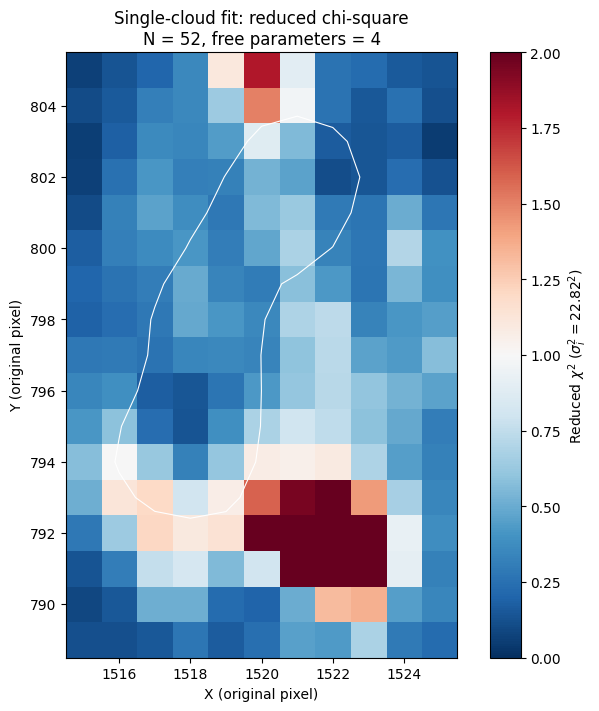

In [81]:
run_dir = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud\run_20260909_193002_558142_fivepoint_center")
print('原本52个波长点')
fig, ax, chi2_red_single = plot_single_cloud_reduced_chi2(run_dir,save=False)
plt.show()

拉长变成78个波长点
二维数组形状：(17, 11)
空间范围：y=789:806, x=1515:1526
有效自由度：74
约化卡方：min=0.06147, median=0.5883, max=6.903


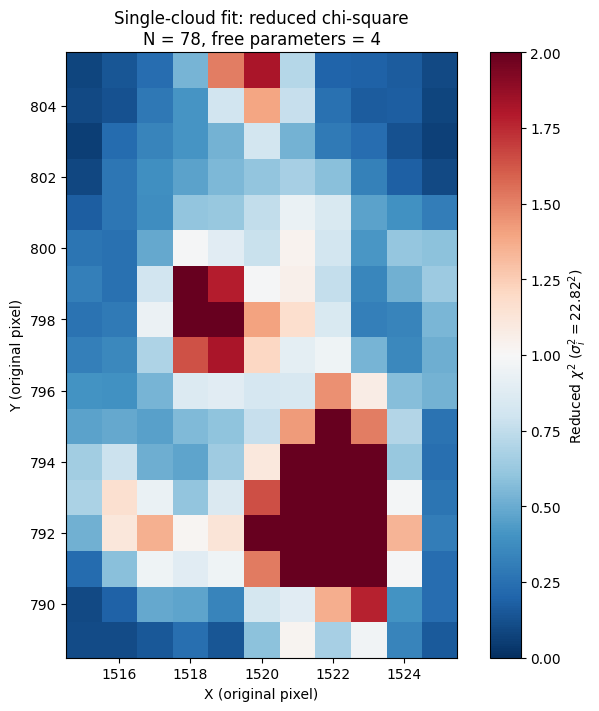

In [82]:
run_dir = Path(r"C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\single_cloud\run_20260915_105108_475167_30_108")
print('拉长变成78个波长点')
fig, ax, chi2_red_single = plot_single_cloud_reduced_chi2(run_dir,save=False)
plt.show()

<font color=cyan>单独看一下之前那个双云模型拟合得到的参数吧</font>  
下面是计算一下平均光谱I，懒得管别的了把画图的部分也带来了

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735


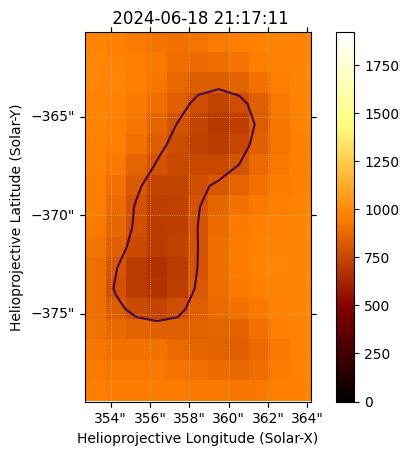

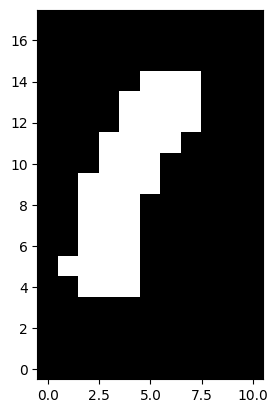

In [53]:
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=30
right_index=108
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])

hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
#生成的蓝翼图像
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

fig=plt.figure()
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
cbar=fig.colorbar(im,ax=ax3)
contour=ax3.contour(jet_region.data,levels=[800],transform=ax3.get_transform(jet_region.wcs))

#-------------------------------------------------------------------------------------------
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)

# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)

# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
# 现在 mask 就是一个布尔数组，True 表示在等值线包围区域内
plt.figure()
plt.imshow(mask, origin='lower', cmap='gray')
#plt.title("等值线区域 mask")
plt.show()

run 01/30, seed=20260706, raw_sse=4094.9, scaled_sse=0.0837108
run 02/30, seed=20260707, raw_sse=6172.82, scaled_sse=0.126189
run 03/30, seed=20260708, raw_sse=6172.82, scaled_sse=0.126189
run 04/30, seed=20260709, raw_sse=4094.9, scaled_sse=0.0837108
run 05/30, seed=20260710, raw_sse=5999.06, scaled_sse=0.122637
run 06/30, seed=20260711, raw_sse=6172.82, scaled_sse=0.126189
run 07/30, seed=20260712, raw_sse=6071.73, scaled_sse=0.124122
run 08/30, seed=20260713, raw_sse=6172.82, scaled_sse=0.126189
run 09/30, seed=20260714, raw_sse=4094.9, scaled_sse=0.0837108
run 10/30, seed=20260715, raw_sse=6237.46, scaled_sse=0.12751
run 11/30, seed=20260716, raw_sse=13054.8, scaled_sse=0.266875
run 12/30, seed=20260717, raw_sse=4094.9, scaled_sse=0.0837108
run 13/30, seed=20260718, raw_sse=6071.73, scaled_sse=0.124122
run 14/30, seed=20260719, raw_sse=6172.82, scaled_sse=0.126189
run 15/30, seed=20260720, raw_sse=4094.9, scaled_sse=0.0837108
run 16/30, seed=20260721, raw_sse=4094.9, scaled_sse=0.0

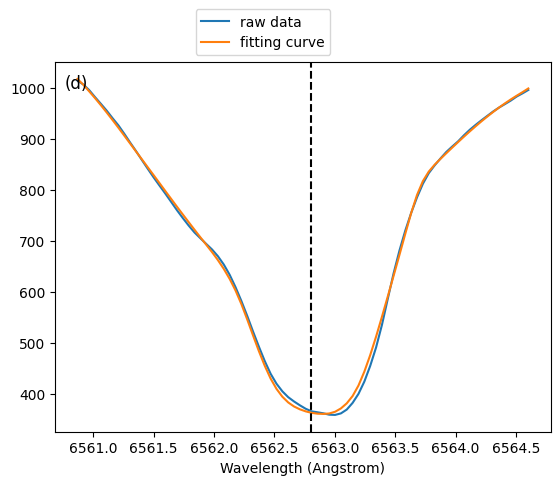

In [54]:
#把mask应用到数据上，得到目标区域的平均光谱曲线
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
spec_data=jet_masked.mean(axis=(1,2))

import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458

# wavelength -> velocity
lam = lam00[left_index:right_index]
vel = (lam - lam0) / lam0 * c_km

I = spec_data
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))
Icont = I0

# =========================
# 1. 数据清理
# =========================
I_fit = np.ma.filled(I, np.nan)
Icont_fit = np.ma.filled(Icont, np.nan)

valid = np.isfinite(vel) & np.isfinite(I_fit) & np.isfinite(Icont_fit)

vel_fit = np.asarray(vel[valid], dtype=float)
I_fit = np.asarray(I_fit[valid], dtype=float)
Icont_fit = np.asarray(Icont_fit[valid], dtype=float)

# 用于残差归一化。只改变数值优化稳定性，不改变最优解位置。
sigma = np.std(I_fit - np.median(I_fit))
if not np.isfinite(sigma) or sigma <= 0:
    sigma = np.mean(np.abs(I_fit)) * 1e-3
if not np.isfinite(sigma) or sigma <= 0:
    sigma = 1.0


# =========================
# 2. 双云模型
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
# =========================
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params

    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)

    tauL = tau0L * np.exp(-((vel - vL) ** 2) / (WL ** 2))
    tauU = tau0U * np.exp(-((vel - vU) ** 2) / (WU ** 2))

    I_model = (
        Icont * np.exp(-(tauL + tauU))
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU)
        + SU * (1 - np.exp(-tauU))
    )

    return I_model


def residuals_scaled(params, vel, I, Icont):
    return (double_cloud_vel(params, vel, Icont) - I) / sigma


def ssq_scaled(params, vel, I, Icont):
    r = residuals_scaled(params, vel, I, Icont)
    return np.sum(r ** 2)


def ssq_raw(params, vel, I, Icont):
    y = double_cloud_vel(params, vel, Icont)
    return np.sum((y - I) ** 2)


# =========================
# 3. 参数范围
# =========================
Imean = np.mean(I_fit)

# 如果出现极窄线宽吃噪声，可以把 W_MIN 改成 0.5 或 1.0
W_MIN = 0.05
W_MAX = 200.0

lb = np.array([
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(W_MIN), np.log(W_MIN), # lWl, lWu
    0.0, 0.0                      # SL, SU
], dtype=float)

ub = np.array([
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(W_MAX), np.log(W_MAX),
    Imean * 10, Imean * 10
], dtype=float)

bounds = list(zip(lb, ub))


# =========================
# 4. 多次全局搜索 + 局部精炼
# =========================
N_GLOBAL_RUNS = 30
BASE_SEED = 20260706

candidates = []

for i in range(N_GLOBAL_RUNS):
    seed = BASE_SEED + i

    result_de = differential_evolution(
        ssq_scaled,
        bounds,
        args=(vel_fit, I_fit, Icont_fit),
        strategy='best1bin',
        maxiter=1500,
        popsize=25,
        tol=1e-8,
        atol=0.0,
        mutation=(0.5, 1.0),
        recombination=0.7,
        seed=seed,
        init='sobol',
        polish=False,
        updating='immediate',
        workers=1
    )

    # 用和 DE 完全一致的目标函数做局部精炼。
    # 注意这里不使用 soft_l1，因为 soft_l1 会改变优化目标。
    lsq = least_squares(
        residuals_scaled,
        result_de.x,
        args=(vel_fit, I_fit, Icont_fit),
        bounds=(lb, ub),
        loss='linear',
        x_scale=np.array([
            1.0, 1.0,       # ltauL, ltauU
            50.0, 50.0,     # vL, vU
            1.0, 1.0,       # lWl, lWu
            max(Imean, 1), max(Imean, 1)
        ]),
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        max_nfev=10000
    )

    scaled_sse = ssq_scaled(lsq.x, vel_fit, I_fit, Icont_fit)
    raw_sse = ssq_raw(lsq.x, vel_fit, I_fit, Icont_fit)

    candidates.append({
        "seed": seed,
        "x": lsq.x,
        "raw_sse": raw_sse,
        "scaled_sse": scaled_sse,
        "de_fun": result_de.fun,
        "lsq_cost": lsq.cost,
        "success": lsq.success,
        "message": lsq.message
    })

    print(
        f"run {i + 1:02d}/{N_GLOBAL_RUNS}, "
        f"seed={seed}, raw_sse={raw_sse:.6g}, scaled_sse={scaled_sse:.6g}"
    )


# =========================
# 5. 选择最优候选
# =========================
candidates = sorted(candidates, key=lambda d: d["raw_sse"])
best = candidates[0]
x_opt = best["x"]

print("\n===== best candidate =====")
print("best seed:", best["seed"])
print("best raw SSE:", best["raw_sse"])
print("best scaled SSE:", best["scaled_sse"])
print("least_squares success:", best["success"])
print("least_squares message:", best["message"])

print("\n===== top 5 candidates =====")
for k, cand in enumerate(candidates[:5], start=1):
    print(
        f"{k}: seed={cand['seed']}, "
        f"raw_sse={cand['raw_sse']:.8g}, "
        f"scaled_sse={cand['scaled_sse']:.8g}"
    )


# =========================
# 6. 拆解结果
# =========================
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt

tau0L = np.exp(ltauL)
tau0U = np.exp(ltauU)
WL = np.exp(lWl)
WU = np.exp(lWu)

print("\n===== fitted parameters =====")
print(f"SL={SL:.6g}, SU={SU:.6g}")
print(f"tau0L={tau0L:.6g}, tau0U={tau0U:.6g}")
print(f"vL={vL:.6g} km/s, vU={vU:.6g} km/s")
print(f"WL={WL:.6g} km/s, WU={WU:.6g} km/s")


# =========================
# 7. 作图
# =========================
y_fit = double_cloud_vel(x_opt, vel, Icont)

print("\n拟合误差:", np.sum((np.ma.filled(I, np.nan) - y_fit) ** 2))

fig, ax = plt.subplots()
ax.plot(lam, I, label='raw data')
ax.plot(lam, y_fit, label='fitting curve')
ax.text(0.02, 0.93, '(d)', color='black', transform=ax.transAxes, fontsize=12)
ax.axvline(lam0, linestyle='--', color='black')
ax.legend(bbox_to_anchor=(0.27, 1))
ax.set_xlabel('Wavelength (Angstrom)')
plt.show()

约化卡方为： 0.11637889886293719


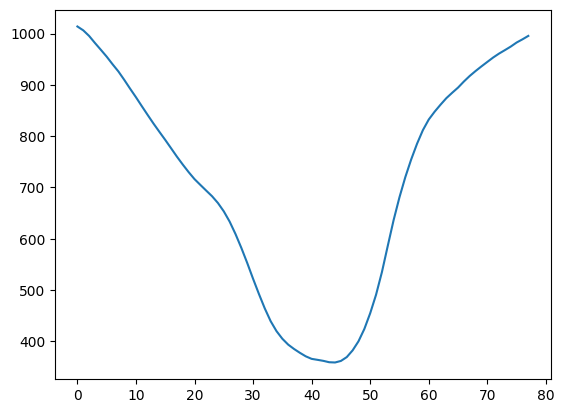

In [56]:
plt.plot(I)
red_chi_squared=np.sum(((I-y_fit)**2)/22.42**2)/(len(I)-8)
print('约化卡方为：', red_chi_squared)

原本的拟合

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00
vL= -15.66921234951098 km/s vU= 20.54882393973615 km/s


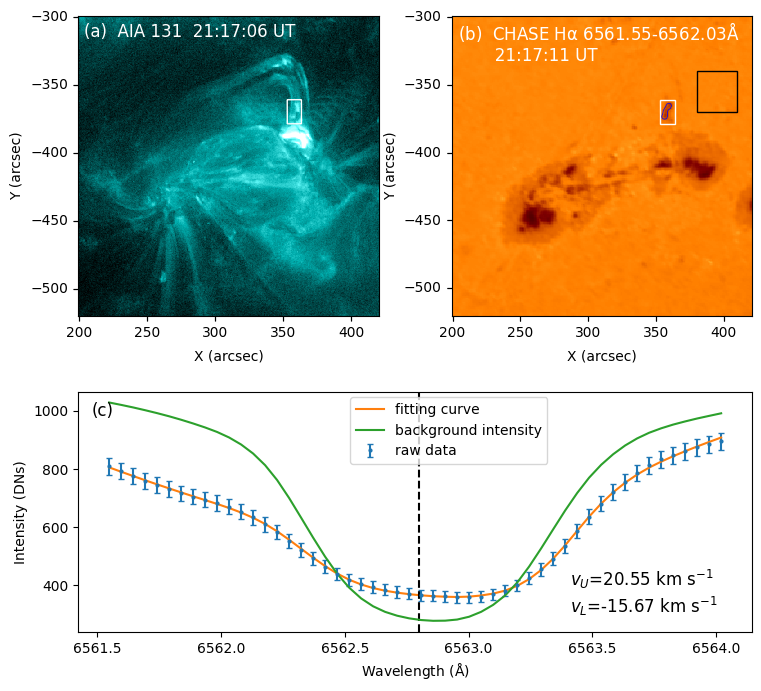

In [57]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I,vL,vU


import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

# 数据准备
dir = r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm = fits.open(dir)

left_index = 44
right_index = 96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam00[left_index:right_index]  # ±1.5A
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))

print(lam00[39], lam00[44], lam00[54], lam00[96], lam00[101])

lam0 = 6562.8
c_km = 299792.458
vel = (lam - lam0) / lam0 * c_km  # km/s

# 画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime='2024-06-18 21:17:11', observer='earth', frame=frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS, reference_pixel=[rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel, scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(left_bottom, top_right=top_right)

# aia131 图像
dir2 = r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia = sunpy.map.Map(dir2)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=aia.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=aia.coordinate_frame)
sub_aia = aia.submap(left_bottom, top_right=top_right)

# ----------------------------------------------------------------------------------------------------------------------------
# 图1
fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(2, 1, hspace=0.28, height_ratios=[1, 0.8])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.15, width_ratios=[1, 1])

old_norm = sub_aia.plot_settings['norm']
old_norm.vmin = 0.01
old_norm.vmax = 2000

ax1 = fig.add_subplot(gs_top[0], projection=sub_aia)
sub_aia.plot(axes=ax1, norm=old_norm)

# ------------------------------------------------------------------------------------------------------------------
# 图2
ax2 = fig.add_subplot(gs_top[1], projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2, cmap='afmhot', vmin=0, vmax=2 * sub_hawing_map.data.mean())

# point1 是宁静区左下角
point1 = SkyCoord(Tx=380 * u.arcsec, Ty=-370 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix1, ypix1 = hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')

# point2 是宁静区右上角
point2 = SkyCoord(Tx=410 * u.arcsec, Ty=-340 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix2, ypix2 = hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')

sub_hawing_map.draw_quadrangle(point1, top_right=point2, axes=ax2, edgecolor='black')

jet_point = (1520, 791)
point3 = hawing_map.wcs.pixel_to_world(jet_point[0], jet_point[1])
xpix3, ypix3 = hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')

# point4 是喷流选取左下角
jet_point4 = (1515, 789)
point4 = hawing_map.wcs.pixel_to_world(jet_point4[0], jet_point4[1])
xpix4, ypix4 = hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')

# point5 是喷流选取右上角
jet_point5 = (1525, 806)
point5 = hawing_map.wcs.pixel_to_world(jet_point5[0], jet_point5[1])
xpix5, ypix5 = hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4, top_right=point5, axes=ax2, edgecolor='white')
sub_aia.draw_quadrangle(point4, top_right=point5, axes=ax1, edgecolor='white')

# 喷流小区域
jet_region = sub_hawing_map.submap(point4, top_right=point5)

# b 图中显示 contour
contour_b = ax2.contour(jet_region.data, levels=[800], colors=['blue'], linewidths=0.5, transform=ax2.get_transform(jet_region.wcs))

# -------------------------------------------------------------------------------------------------
# 关键：不画原来的 C 小图，但仍然用 jet_region.data 生成一个 contour 来算 mask/raw data
from matplotlib.path import Path

fig_tmp, ax_tmp = plt.subplots()
contour_for_mask = ax_tmp.contour(jet_region.data, levels=[800], colors=['blue'],linewidths=1)
plt.close(fig_tmp)

mask = np.zeros_like(jet_region.data, dtype=bool)

ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T

for path in contour_for_mask.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)

data_jet = rsm[1].data[left_index:right_index, 789:807, 1515:1526]
data_mask = np.tile(~mask, (right_index - left_index, 1, 1))
jet_masked = np.ma.array(data_jet, mask=data_mask)
I = jet_masked.mean(axis=(1, 2))

# -------------------------------------------------------------------------------------------------
# 新图3：原来的 D 图，现在变成 C 图，占据下面整行
ax3 = fig.add_subplot(gs[1])

x_opt = np.load('x_opt_new.npy')

ax3.errorbar(lam, I, yerr=np.sqrt(I), fmt='o', capsize=2, markersize=2, label='raw data')
y_fit,vL,vU = double_cloud_vel(x_opt, vel, I0)
ax3.plot(lam, y_fit, label='fitting curve')
ax3.axvline(x=6562.8, linestyle='--', color='black')
ax3.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
ax3.set_ylabel('Intensity (DNs)')
ax3.plot(lam,I0,label='background intensity')
ax3.legend(bbox_to_anchor=(0.55, 0.67))

# ---------------------------------------------------------------------------------------------------
# 画图乱七八糟的部分
ax_all = [ax1, ax2]

for ax in ax_all:
    ax.set_xlabel('X (arcsec)', labelpad=1.2)
    ax.set_ylabel('Y (arcsec)')
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True, top=False, labeltop=False)
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, right=False, labelright=False)
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.coords[0].set_major_formatter('s', show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s', show_decimal_unit=False)
    ax.set_title('')

ax_all[0].text(0.02, 0.93, '(a)  AIA 131  21:17:06 UT', color='white', transform=ax_all[0].transAxes, fontsize=12)
ax_all[1].text(0.02, 0.85, r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$' + 
               '\n       21:17:11 UT', color='white', transform=ax_all[1].transAxes, fontsize=12)

ax3.text(0.02, 0.9, '(c)', color='black', transform=ax3.transAxes, fontsize=12)
ax3.text(0.73, 0.08, r'$v_U$' + f'={vU:.2f} ' + r'$\mathrm{km \ s^{-1}}$' + '\n'
          + r'$v_L $' + f'={vL:.2f} ' + r'$\mathrm{km \ s^{-1}}$', color='black', fontsize=12, transform=ax3.transAxes)
# ---------- 让(c)图左右边界与(a)(b)总宽度对齐 ----------
fig.canvas.draw()

pos1 = ax1.get_position()
pos2 = ax2.get_position()
pos3 = ax3.get_position()

left = pos1.x0
right = pos2.x1

ax3.set_position([
    left,
    pos3.y0,
    right - left,
    pos3.height
])
print('vL=',vL,'km/s','vU=',vU,'km/s')
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig6\double_cloud.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)

In [59]:
red_chi_squared=np.sum(((I-y_fit)**2)/22.42**2)/(len(I)-8)
print('约化卡方为：', red_chi_squared)

约化卡方为： 0.028131313161318783
